# Find the Optimal Fiducial Volume

In [78]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
# turn off RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
syst_tag = ""
ret = get_ana_dfs(option="event_selection", syst_tag = syst_tag)

mc_evt_df, mc_trk_df           = ret["mc"], ret["mc_trk"]
data_evt_df, data_trk_df       = ret["data"], ret["data_trk"]
intime_evt_df, intime_trk_df   = ret["intime"], ret["intime_trk"]
dirt_evt_df, dirt_trk_df       = ret["dirt"], ret["dirt_trk"]
offbeam_evt_df, offbeam_trk_df = ret["offbeam"], ret["offbeam_trk"]

pot_str = ret["pot_str"]
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5']
Reading file with tag aa, mc_n_split: 6
Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5']
Reading file w

In [ ]:
save_fig = True
save_nevts = True
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"fiducial_volume-{syst_tag}-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


save_nevts_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts"
if save_nevts:
    if not path.exists(save_nevts_dir):
        makedirs(save_nevts_dir)
    print("saving nevts in ", save_nevts_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/fiducial_volume--20260423
saving nevts in  /exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts


In [5]:
# for event selection summary plot
breakdown_dict = {"topology": {}, "genie": {}}

# save dfs per stage, df_dict used for efficiency plot
df_dict = {} 
df_dict_data = {}
df_dict_intime = {} 
df_dict_offbeam = {}
df_dict_dirt = {}

In [6]:
def plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=True):

    ret_dict = {}

    for bar_type in ["topology", "genie"]: # "nu_cosmics"
        save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
        this_ret = bar_plot(breakdown_type=bar_type,
                            mc_df=mc_df, intime_df=intime_df, dirt_df=dirt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)
        ret_dict[bar_type] = this_ret

    return ret_dict

In [ ]:
mc_df     = mc_evt_df
data_df   = data_evt_df
intime_df = intime_evt_df
offbeam_df = offbeam_evt_df
dirt_df   = dirt_evt_df

In [23]:
stage_key = "is_clear_cosmic"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_clear_cosmic(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

stage_key = "vertex_in_fv"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

stage_key = "nu_score"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

precut 24784
postcut 22552
eff 0.9099418979987088


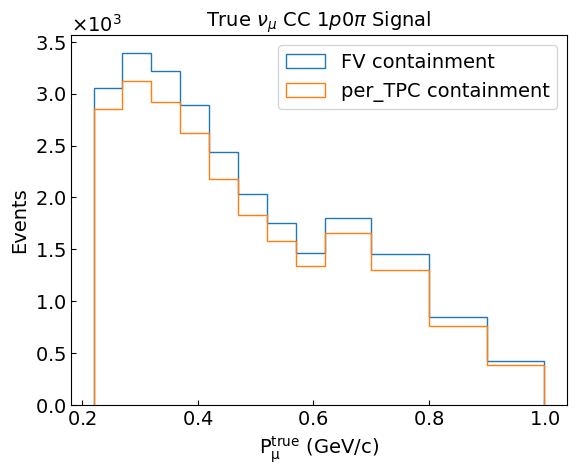

In [85]:
# define new FV: event fully contained in either TPC
# cathode_inset = 5 # cm
# def InFV(df,det="SBND"):
#     if det == "SBND_perTPC":
#         xmin_tpc1 = -190.
#         xmax_tpc1 = -5.
#         xmin_tpc2 = 5.
#         xmax_tpc2 = 190.
        
#     return ((df.x > xmin_tpc1) & (df.x < xmax_tpc1)) | ((df.x > xmin_tpc2) & (df.x < xmax_tpc2))

def IsSignal(df):
    return (df.mc.nmu_220MeVc == 1) & (df.mc.np_300MeVc == 1) & (df.mc.npi_70MeVc == 0) & (df.mc.npi0 == 0) &\
        (np.sqrt(df.mc.mu.genp.x**2 + df.mc.mu.genp.y**2 + df.mc.mu.genp.z**2) < 1) &\
        (np.sqrt(df.mc.p.genp.x**2 + df.mc.p.genp.y**2 + df.mc.p.genp.z**2) < 1) &\
        InFV(df.mc.mu.start, det="SBND") & InFV(df.mc.p.start, det="SBND") &\
        InFV(df.mc.mu.end, det="SBND") & InFV(df.mc.p.end, det="SBND") 

TPC1_cut = InFV(mc_df.slc.vertex, det="SBND_TPC1")
TPC2_cut = InFV(mc_df.slc.vertex, det="SBND_TPC2")
mu_perTPC_cut = InFV(mc_df.mc.mu.end, det="SBND_TPC1") | InFV(mc_df.mc.mu.end, det="SBND_TPC2")
p_perTPC_cut = InFV(mc_df.mc.p.end, det="SBND_TPC1") | InFV(mc_df.mc.p.end, det="SBND_TPC2")
vertex_perTPC_cut = InFV(mc_df.slc.vertex, det="SBND_TPC1") | InFV(mc_df.slc.vertex, det="SBND_TPC2")
perTPC_cut = vertex_perTPC_cut & mu_perTPC_cut & p_perTPC_cut
signal_cut = IsSignal(mc_df)

mc_df_signal = mc_df[signal_cut]
mc_df_signal_perTPC = mc_df[perTPC_cut & signal_cut]

print("precut", len(mc_df_signal))
print("postcut", len(mc_df_signal_perTPC))
print("eff", len(mc_df_signal_perTPC)/ len(mc_df_signal))


var_config = VariableConfig.muon_momentum()
bins = var_config.bins

var = mc_df_signal[var_config.var_nu_col]
plt.hist(var, bins=bins, histtype="step", label="FV containment")

var = mc_df_signal_perTPC[var_config.var_nu_col]
plt.hist(var, bins=bins, histtype="step", label="per_TPC containment")

plt.legend()
plt.xlabel(var_config.var_labels[2])
plt.ylabel("Events")
plt.title(r"True $\nu_{\mu}$ CC 1$p$0$\pi$ Signal")
plt.show();

In [84]:
def IsSignal(df):
    return (df.mc.nmu_220MeVc == 1) & (df.mc.np_300MeVc == 1) & (df.mc.npi_70MeVc == 0) & (df.mc.npi0 == 0) &\
        InFV(df.mc.mu.start, det="SBND") & InFV(df.mc.p.start, det="SBND") &\
        InFV(df.mc.mu.end, det="SBND") & InFV(df.mc.p.end, det="SBND") 

perTPC_cut = InFV(mc_df.slc.vertex, det="SBND_perTPC")
perTPC_cut = InFV(mc_df.slc.vertex, det="SBND_perTPC") & InFV(mc_df.mc.mu.end, det="SBND_perTPC") & InFV(mc_df.mc.p.end, det="SBND_perTPC")
signal_cut = IsSignal(mc_df)

mc_df_signal = mc_df[signal_cut]
mc_df_signal_perTPC = mc_df[perTPC_cut & signal_cut]

print("precut", len(mc_df_signal))
print("postcut", len(mc_df_signal_perTPC))
print("eff", len(mc_df_signal_perTPC)/ len(mc_df_signal))


var_config = VariableConfig.muon_momentum()
bins = var_config.bins

var = mc_df_signal[var_config.var_nu_col]
plt.hist(var, bins=bins, histtype="step", label="FV containment")

var = mc_df_signal_perTPC[var_config.var_nu_col]
plt.hist(var, bins=bins, histtype="step", label="per_TPC containment")

plt.legend()
plt.xlabel(var_config.var_labels[2])
plt.ylabel("Events")
plt.title(r"True $\nu_{\mu}$ CC 1$p$0$\pi$ Signal")
plt.show();

NameError: DETECTOR not valid, should be SBND or ICARUS

In [34]:
# var_config = VariableConfig.vertex_x()
var_config = VariableConfig.muon_direction_phi()
plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]

plot_type = "topology"
save_name = save_fig_dir + "/selected-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist_topo = overlay_hists(plot_type,
                                mc_df=mc_df, 
                                data_df=data_df, 
                                intime_df=intime_df, 
                                dirt_df=dirt_df,
                                # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config),
                                ratio=True,
                                ax_ylim_ratio=1.7,
                                # vline=[[NU_SCORE_TH, 1]],
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

KeyError: 'Key length (7) exceeds index depth (5)'

In [24]:
mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_df), (data_trk_df, data_df), (intime_trk_df, intime_df), (offbeam_trk_df, offbeam_df), (dirt_trk_df, dirt_df))
)

no syst provided


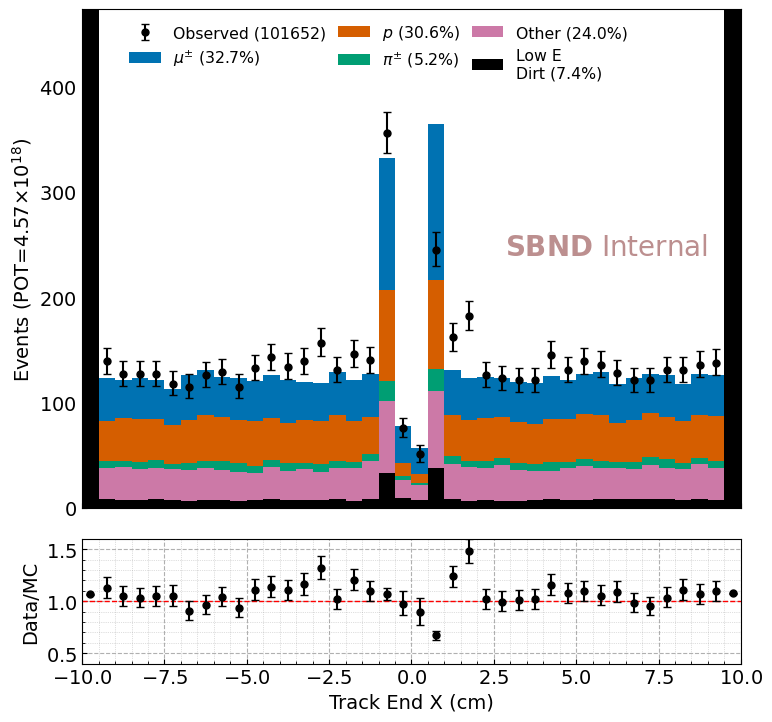

In [33]:
plot_type = "pdg"

var_config = VariableConfig.track_end_x()

plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                         mc_df=mc_trk_df, 
                         data_df=data_trk_df, 
                         intime_df=intime_trk_df, 
                         dirt_df=dirt_trk_df,
                        #  syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                         ratio=True,
                         ax_ylim_ratio=0.01,
                        #  vline=[[0.5, 1]],
                         var_config=var_config,
                         plot_labels=plot_labels,
                         save_fig=save_fig, 
                         save_name=save_name)